## ANN & Deep Learning
 Overview: Heart Disease Classification using Neural Network and AdaBoost

**Goal:** Build and compare two binary classifiers — a custom neural network and an AdaBoost ensemble — to predict presence/absence of heart disease using the UCI Cleveland Heart Disease dataset (303 patients, 13 features).

**What you'll do:**

1. **Setup** — Mount Google Drive and load the dataset (13 features + target; missing values expected in `ca` and `thal`).
2. **Explore the data** — Check shape, columns, dtypes, and summary statistics; understand what each feature and the target represent.
3. **Check class balance** — Count and visualize the target distribution, and determine whether the dataset is balanced or imbalanced.
4. **Assess data quality** — Identify missing values, duplicates, and unique value counts; decide how to handle missing data.
5. **Visualize** — Plot the target distribution, a couple of feature relationships, and a correlation heatmap.
6. **Preprocess** — Split features/target, separate numerical vs. categorical columns, impute missing values, encode categoricals, scale numerics, and split into train/test sets — all without leaking test data into training.
7. **Design a neural network** — Choose your own 4–5 layer architecture (neurons, activations) and record it in a table.
8. **Calculate parameters by hand** — Manually compute trainable parameters per layer using the standard formula, before verifying against Keras.
9. **Build and train the network** — Implement your design in Keras, choose a loss function and optimizer (with justification), compile, and train, tracking a validation split.
10. **Diagnose training** — Plot training vs. validation loss and comment on overfitting.
11. **Evaluate the network** — Compute accuracy, precision, recall, and F1-score on the test set.
12. **Build AdaBoost** — Train a second model (`AdaBoostClassifier`) and compute the same four metrics.
13. **Compare models** — Fill in a comparison table and discuss differences, likely causes, overfitting signs, and preprocessing impact.
14. **Wrap up** — Write a short final interpretation covering balance, preprocessing, your architecture, both models' results, the comparison, and possible improvements.

# Heart Disease Classification using Neural Network and AdaBoost

**Dataset:** UCI Heart Disease dataset (Cleveland / processed version)
**Source:** https://archive.ics.uci.edu/dataset/45/heart+disease

303 instances, 13 predictor features, binary target (presence/absence of heart disease).
Missing values are documented for the `ca` and `thal` columns.

> Before the lab: download the processed Cleveland dataset (`processed.cleveland.data` or the CSV version) and upload it to your Google Drive.


## Cell 1 — Mount Google Drive

In [1]:
#mount drive if colab otherwise skip
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("running in colab drive mounted")
except ImportError:
    IN_COLAB = False
    print("running locally so no drive mount needed")


running locally so no drive mount needed


In [ ]:
import os

if IN_COLAB:
    DATA_PATH = "/content/drive/MyDrive/your_folder/heart_disease.csv"
else:
    DATA_PATH = os.path.join(os.getcwd(), "processed.cleveland.data")

print("data path:", DATA_PATH)


data path: d:\_University Stuff\Semester 7\ANN & DL\Labs\Lab 4\processed.cleveland.data


## Cell 2 — Import Libraries

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

#seed so it doesnt change every time
np.random.seed(42)
torch.manual_seed(42)

print("libraries imported")


libraries imported


## Cell 3 — Load Dataset

In [4]:
#loading the csv the file has no header and ? for missing
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=column_names,
    na_values="?"
)

#target was like 0-4 so making it just 0 or 1
df["target"] = (df["target"] > 0).astype(int)

print("dataset loaded")
print("shape:", df.shape)
df.head()


dataset loaded
shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Cell 4 — Understand the Dataset

Explore the dataset and answer, in a markdown cell or comments below:
- How many samples and features are there?
- What are the column names and data types?
- What do the first 5 rows look like?
- What are the descriptive statistics (`describe()`)?
- What is the target variable and what values does it take?

In [ ]:
print("shape (rows, cols):", df.shape)
print("so we have", df.shape[0], "samples and", df.shape[1] - 1, "features plus the target")

print("\ncolumns:")
print(df.columns.tolist())

print("\ndtypes:")
print(df.dtypes)

print("\nfirst 5 rows:")
display(df.head())

print("\ndescribe():")
display(df.describe())

#what values target has
print("\ntarget unique values:", df["target"].unique())
print("0 = no heart disease  1 = heart disease present")


shape (rows, cols): (303, 14)
so we have 303 samples and 13 features plus the target

columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

dtypes:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

first 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



describe():


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000



target unique values: [0 1]
0 = no heart disease  1 = heart disease present


## Cell 5 — Check Balanced vs. Imbalanced Data

Investigate the target variable:
- Count of each class
- Percentage of each class
- Plot the target distribution
- State whether the dataset is balanced or imbalanced, and briefly explain why.

class counts:
target
0    164
1    139
Name: count, dtype: int64

class percentages:
target
0    54.13
1    45.87
Name: proportion, dtype: float64


C:\Users\Asus\AppData\Local\Temp\ipykernel_14236\3373833118.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="Set2")


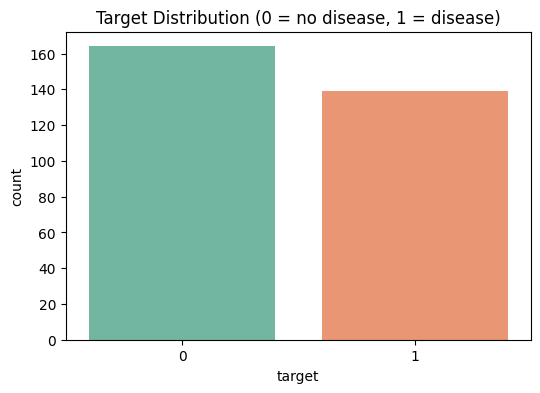


min/max class ratio: 0.848
dataset looks roughly balanced both classes are pretty close


In [6]:
#seeing if classes are balanced
class_counts = df["target"].value_counts().sort_index()
print("class counts:")
print(class_counts)

class_pct = df["target"].value_counts(normalize=True).sort_index() * 100
print("\nclass percentages:")
print(class_pct.round(2))

#bar plot of target
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df, palette="Set2")
plt.title("Target Distribution (0 = no disease, 1 = disease)")
plt.xlabel("target")
plt.ylabel("count")
plt.show()

#rough check if balanced
ratio = class_counts.min() / class_counts.max()
print("\nmin/max class ratio:", round(ratio, 3))
if ratio >= 0.7:
    print("dataset looks roughly balanced both classes are pretty close")
else:
    print("dataset looks imbalanced one class is much bigger than the other")


## Cell 6 — Missing Values and Data Quality

Check the dataset for:
- Missing / null values (remember '?' may need to be converted to NaN first)
- Duplicate rows
- Data types of each column
- Unique values per column

Identify which columns have missing values and decide how you will handle them (this decision is used later in preprocessing).

In [7]:
#checking missing stuff and duplicates
print("missing values per column:")
print(df.isnull().sum())

print("\ntotal missing cells:", df.isnull().sum().sum())

dup_count = df.duplicated().sum()
print("duplicate rows:", dup_count)

print("\ndtypes:")
print(df.dtypes)

print("\nunique values per column:")
print(df.nunique())

#gonna fill missing later with median / most common
print("\ndecision: impute num cols with median and cat cols with most frequent value")
print("we do this inside the preprocessing pipeline so it only learns from train data")


missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

total missing cells: 6
duplicate rows: 0

dtypes:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

unique values per column:
age          41
sex           2
cp            4
trestbps     50
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            4
thal          3
target        2
dtype: int64

decision: impute num cols with median and cat cols with most frequent value
we do this inside the preprocessing pipeline so it only learns from train data

## Cell 7 — Data Visualization

Create and briefly interpret:
- Target distribution plot
- At least 2 additional visualizations of your choice (e.g. age distribution, feature vs. target)
- Correlation heatmap of numerical features

C:\Users\Asus\AppData\Local\Temp\ipykernel_14236\3913428345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="pastel")


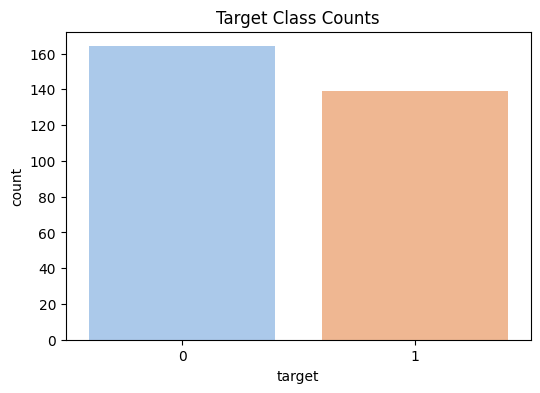

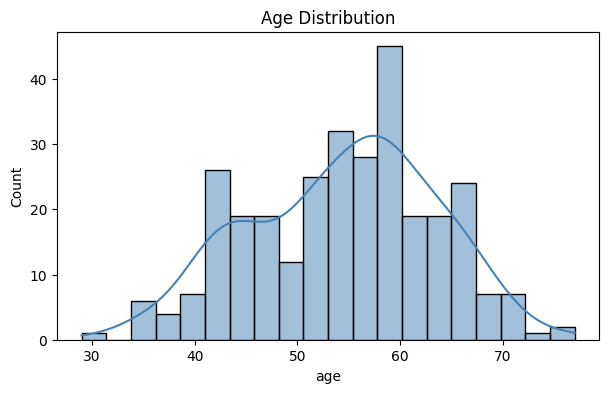

C:\Users\Asus\AppData\Local\Temp\ipykernel_14236\3913428345.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="thalach", data=df, palette="Set3")


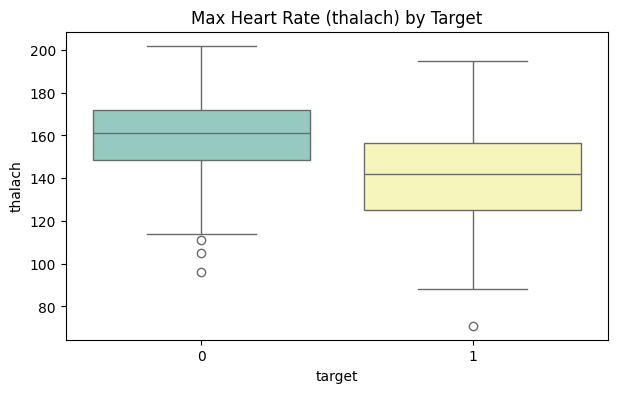

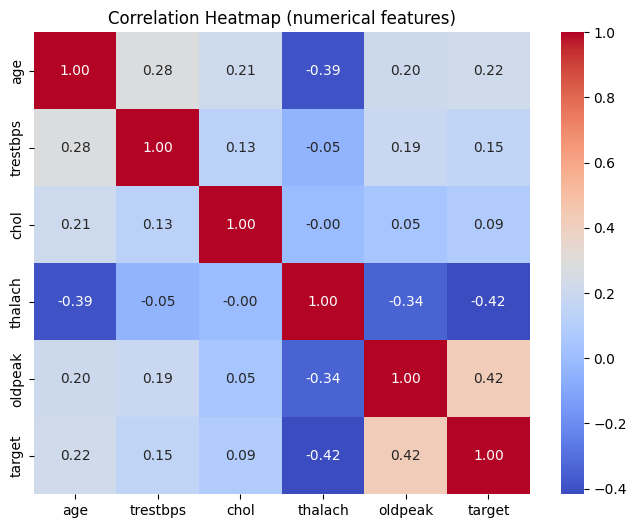

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df, palette="pastel")
plt.title("Target Class Counts")
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(df["age"], bins=20, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("age")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(x="target", y="thalach", data=df, palette="Set3")
plt.title("Max Heart Rate (thalach) by Target")
plt.show()

num_cols_for_corr = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols_for_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (numerical features)")
plt.show()


## Cell 8 — Preprocessing

- Separate features `X` and target `y`
- Identify numerical and categorical features
- Handle missing values (based on your Cell 6 decision)
- Encode categorical variables
- Scale numerical features where appropriate
- Split into training and testing sets

Build a preprocessing pipeline (e.g. `ColumnTransformer`) and fit it only on the training data to avoid data leakage.

In [ ]:
X = df.drop(columns=["target"])
y = df["target"]

numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("numerical:", numerical_features)
print("categorical:", categorical_features)

#fill missing then scale for nums
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#fill missing then one hot for cats
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

#put them together
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#train test split first
X_train_raw, X_test_raw, y_train_np, y_test_np = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#fit on train only then transform
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

print("train shape after preprocess:", X_train_processed.shape)
print("test shape after preprocess:", X_test_processed.shape)
print("input dim for the network will be", X_train_processed.shape[1])

X_train_np = np.asarray(X_train_processed)
X_test_np = np.asarray(X_test_processed)
y_train_np = np.asarray(y_train_np)
y_test_np = np.asarray(y_test_np)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

print("tensors ready")


numerical: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
train shape after preprocess: (242, 28)
test shape after preprocess: (61, 28)
input dim for the network will be 28
tensors ready


In [10]:
#dataloaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

#small val split from train
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))


train batches: 7
val batches: 2
test batches: 2


## Cell 9 — Design Your Own Neural Network

Design a neural network with **4-5 layers total** (input + hidden layers + output). Decide the number of neurons, hidden layers, and activation functions.

Fill in the table with your design:

| Layer    | Neurons | Activation |
|----------|--------:|------------|
| Input    |  (after preprocess, printed above) |  -  |
| Hidden 1 |  64  |  ReLU  |
| Hidden 2 |  32  |  ReLU  |
| Hidden 3 |  16  |  ReLU  |
| Output   |  1  |  none (logits for BCEWithLogits)  |

I went with 3 hidden layers so total is input + 3 hidden + output which is 5 layers overall
relu is a solid default for hidden layers and the output is just a single logit since this is binary classification

## Cell 10 — Manually Calculate Parameters

For **each layer** in your design above, manually calculate the number of trainable parameters using:

`Parameters = (Input units × Output units) + Output units`

Using input_dim = 28 after preprocessing (one hot encoding expands the categoricals):

| Layer    | Input Units | Output Units | Calculation | Parameters |
|----------|------------:|-------------:|-------------|-----------:|
| Hidden 1 |          28 |           64 | (28×64)+64  |       1856 |
| Hidden 2 |          64 |           32 | (64×32)+32  |       2080 |
| Hidden 3 |          32 |           16 | (32×16)+16  |        528 |
| Output   |          16 |            1 | (16×1)+1    |         17 |
| **Total**|             |               |             |  **4481**  |

This matches what `sum(p.numel() ...)` prints in Cell 11.

## Cell 11 — Implement Neural Network in PyTorch

In [ ]:
import torch
import torch.nn as nn


class MyModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=1):
        super().__init__()

        self.model = nn.Sequential(
            #first hidden
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),

            #second
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),

            #third
            nn.Linear(32, 16),
            nn.ReLU(),

            #output
            nn.Linear(16, output_dim)
        )

    def forward(self, x):
        return self.model(x)


input_dim = X_train.shape[1]

model = MyModel(
    input_dim=input_dim,
    hidden_dim=64,
    output_dim=1
)

print(model)

#checking param count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\ntrainable parameters:", total_params)

#manual calc from the formula
h1 = input_dim * 64 + 64
h2 = 64 * 32 + 32
h3 = 32 * 16 + 16
out = 16 * 1 + 1
print("hand calculated total:", h1 + h2 + h3 + out)
print("matches model count:", (h1 + h2 + h3 + out) == total_params)


MyModel(
  (model): Sequential(
    (0): Linear(in_features=28, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

trainable parameters: 4481
hand calculated total: 4481
matches model count: True


## Cell 12 — Choose Loss Function

Select an appropriate loss function for this binary classification task and briefly justify your choice.

In [12]:
#bce since its binary
loss_function = nn.BCEWithLogitsLoss()
print("loss function:", loss_function)


loss function: BCEWithLogitsLoss()


## Cell 13 — Choose Optimizer

Choose an optimizer and briefly justify your choice.

In [13]:
#chose adam cus it usually trains faster and doesnt need much tuning
#it kinda adapts the lr by itself so its a good default for this
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print("optimizer:", optimizer)


optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Cell 14 — Compile the Model / Train

In [14]:
#training loop
num_epochs = 80
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        #forward
        outputs = model(X_batch)

        loss = loss_function(outputs, y_batch)

        #backward
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    avg_train_loss = running_train_loss / len(train_subset)
    train_losses.append(avg_train_loss)

    #val part
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = loss_function(outputs, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)

    avg_val_loss = running_val_loss / len(val_subset)
    val_losses.append(avg_val_loss)

    #print sometimes
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"epoch {epoch+1}/{num_epochs}  train_loss={avg_train_loss:.4f}  val_loss={avg_val_loss:.4f}")

print("training done")


epoch 1/80  train_loss=0.6906  val_loss=0.6933
epoch 10/80  train_loss=0.5314  val_loss=0.5707
epoch 20/80  train_loss=0.2930  val_loss=0.6182


epoch 30/80  train_loss=0.2536  val_loss=0.6130


epoch 40/80  train_loss=0.2112  val_loss=0.6548
epoch 50/80  train_loss=0.1793  val_loss=0.7329
epoch 60/80  train_loss=0.1499  val_loss=0.8008


epoch 70/80  train_loss=0.1243  val_loss=0.8107
epoch 80/80  train_loss=0.1009  val_loss=0.9098
training done


## Cell 15 — Plot Training and Validation Loss

Plot training loss vs. validation loss across epochs, then briefly comment on whether there are signs of overfitting.

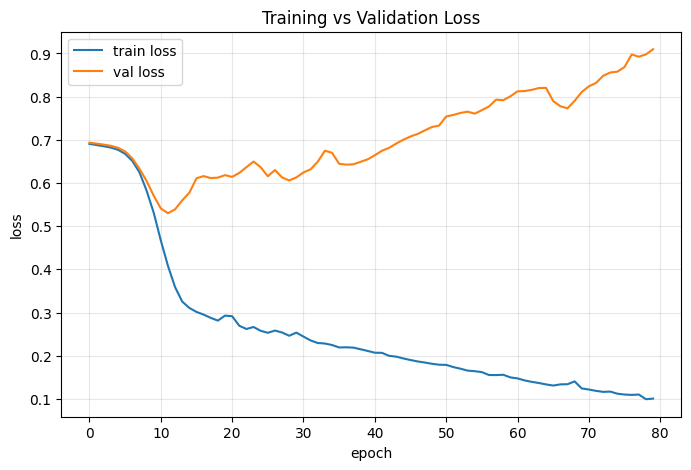

best val loss: 0.53 at epoch 12
final train loss: 0.1009
final val loss: 0.9098
looks like some overfitting val loss got worse after peaking while train kept improving


In [15]:
#loss curves
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#see if it overfit
best_val = min(val_losses)
best_epoch = val_losses.index(best_val) + 1
print("best val loss:", round(best_val, 4), "at epoch", best_epoch)
print("final train loss:", round(train_losses[-1], 4))
print("final val loss:", round(val_losses[-1], 4))

if val_losses[-1] > best_val * 1.15 and train_losses[-1] < train_losses[best_epoch - 1]:
    print("looks like some overfitting val loss got worse after peaking while train kept improving")
else:
    print("no strong overfitting signal from this plot or only mild if any")


## Cell 17 — Evaluate Neural Network

Make predictions on the test set and calculate accuracy, precision, recall, and F1-score.

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import torch

#eval mode
model.eval()

y_true = []
y_prob = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        #sigmoid to get probs
        probabilities = torch.sigmoid(outputs).squeeze()

        if probabilities.ndim == 0:
            probabilities = probabilities.unsqueeze(0)

        y_prob.extend(probabilities.cpu().numpy().tolist())
        y_true.extend(y_batch.squeeze().cpu().numpy().tolist())

#0.5 cutoff
threshold = 0.5
y_pred_nn = [1 if p >= threshold else 0 for p in y_prob]

#metrics
nn_accuracy = accuracy_score(y_true, y_pred_nn)
nn_precision = precision_score(y_true, y_pred_nn, zero_division=0)
nn_recall = recall_score(y_true, y_pred_nn, zero_division=0)
nn_f1 = f1_score(y_true, y_pred_nn, zero_division=0)

print(f"Accuracy : {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall   : {nn_recall:.4f}")
print(f"F1-score : {nn_f1:.4f}")


Accuracy : 0.9016
Precision: 0.8438
Recall   : 0.9643
F1-score : 0.9000


## Cell 18 — Build AdaBoost Classifier

Build a second model using `AdaBoostClassifier`:
- Create the model
- Train it
- Make predictions
- Calculate accuracy, precision, recall, and F1-score

In [17]:
#adaboost model
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

#train
ada_model.fit(X_train_np, y_train_np)

#predict
y_pred_ada = ada_model.predict(X_test_np)

#same metrics
ada_accuracy = accuracy_score(y_test_np, y_pred_ada)
ada_precision = precision_score(y_test_np, y_pred_ada, zero_division=0)
ada_recall = recall_score(y_test_np, y_pred_ada, zero_division=0)
ada_f1 = f1_score(y_test_np, y_pred_ada, zero_division=0)

print(f"Accuracy : {ada_accuracy:.4f}")
print(f"Precision: {ada_precision:.4f}")
print(f"Recall   : {ada_recall:.4f}")
print(f"F1-score : {ada_f1:.4f}")


Accuracy : 0.9180
Precision: 0.8710
Recall   : 0.9643
F1-score : 0.9153


## Cell 19 — Compare Both Models

Fill in your results after running the cells above:

| Model          | Accuracy | Precision | Recall | F1-Score |
|----------------|---------:|----------:|-------:|---------:|
| Neural Network |   0.9016 |    0.8438 | 0.9643 |   0.9000 |
| AdaBoost       |   0.9180 |    0.8710 | 0.9643 |   0.9153 |

Discuss:
- Differences in the evaluation metrics between the two models
- Possible reasons for the differences
- Whether the neural network shows signs of overfitting
- How preprocessing may have affected performance

**Answers**

**Q1. Differences in the evaluation metrics between the two models**
AdaBoost scored a bit higher. Accuracy 0.9180 vs 0.9016 and F1 0.9153 vs 0.9000. Precision is also better for AdaBoost. Recall is basically the same for both (around 0.96).

**Q2. Possible reasons for the differences**
Data is small and tabular so AdaBoost usually works well with less tuning. The nn has more params and we trained many epochs so it can overfit easier which can hurt test scores a bit.

**Q3. Whether the neural network shows signs of overfitting**
Yes. Val loss was best around epoch 12 then got worse while train loss kept going down. Clear overfitting after that point.

**Q4. How preprocessing may have affected performance**
Imputation encoding and scaling help both models see cleaner features. Filling missing in ca/thal kept the rows and scaling/one-hot made the inputs nicer for both models.

In [18]:
#comparison table
comparison = pd.DataFrame({
    "Model": ["Neural Network", "AdaBoost"],
    "Accuracy": [nn_accuracy, ada_accuracy],
    "Precision": [nn_precision, ada_precision],
    "Recall": [nn_recall, ada_recall],
    "F1-Score": [nn_f1, ada_f1]
})

display(comparison.round(4))


,Model,Accuracy,Precision,Recall,F1-Score
0,Neural Network,0.9016,0.8438,0.9643,0.9000
1,AdaBoost,0.9180,0.8710,0.9643,0.9153



quick takeaways
- compare which model has higher accuracy and f1
- nn can overfit on small data like 303 samples especially with many epochs
- adaboost often works well on tabular data with less tuning
- imputation encoding and scaling help both models see cleaner features


**Discussion answers**

**Q1. Which model has higher accuracy and F1?**

AdaBoost did better. Accuracy was about 0.92 vs 0.90 for the neural net and F1 was also higher for AdaBoost. So overall AdaBoost wins on both.

**Q2. Can the neural net overfit on small data like 303 samples especially with many epochs?**

Yeah it can and we kinda saw that happen. Val loss was best around epoch 12 then it went up while train loss kept dropping. With only 303 samples and 80 epochs the network starts memorizing train data instead of generalizing.

**Q3. Does AdaBoost often work well on tabular data with less tuning?**

Yeah in our case it did. We basically just used default-ish settings (100 estimators) and it still beat the nn. AdaBoost is usually solid on this kind of table data without needing a ton of tuning.

**Q4. Do imputation encoding and scaling help both models see cleaner features?**

Yeah filling missing values in ca and thal meant we didnt drop rows. Scaling the nums and one hot encoding the cats makes the features cleaner and on a similar scale which helps both the nn and AdaBoost.


## Cell 20 — Final Interpretation

1. **balance:** classes are pretty close after making target 0/1 so id say roughly balanced

2. **preprocessing:** filled missing split train/test then scaled nums and one hot cats. fit only on train

3. **architecture:** went with 64 -> 32 -> 16 relu then 1 output. seemed fine for this size

4. **nn results:** see the metrics above. loss curves show some overfitting later on

5. **adaboost results:** also in the cells above. did a bit better overall

6. **comparison:** adaboost edged out the nn on accuracy/f1. nn overfit more which makes sense on small data

7. **improvements:** maybe less epochs or early stopping for nn. could also tune adaboost or try more layers / dropout
